<a href="https://colab.research.google.com/github/mbarcodia/teaching_tools/blob/main/pytorch_weather_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch for Weather & Climate Science
### A Hands-On Introduction for Atmospheric & Oceanic Researchers
# CAN YOU SEE THIS CHANGE?
---

**Estimated time:** 10–15 minutes  
**Prerequisites:** Python, NumPy, basic familiarity with linear regression  
**What you'll learn:** How to think in PyTorch tensors, run GPU operations, and build a small neural network — all framed around weather data.

---

### Why PyTorch for Atmospheric Science?

Modern weather and climate research increasingly relies on deep learning:
- **Downscaling** coarse-resolution model output
- **Emulating** expensive GCM parameterizations
- **Forecasting** extreme events from reanalysis data (e.g., ERA5)
- **Correcting** model bias against observations

PyTorch is the dominant framework for this work. This notebook gives you the core building blocks.

---

**Sections:**
1. [Setup](#setup)
2. [Tensor Basics](#tensors)
3. [Simple Weather Example](#weather-example)
4. [Automatic Differentiation](#autograd)
5. [Mini Neural Network](#neural-network)
6. [NumPy vs PyTorch](#numpy-vs-pytorch)

---
## 1. Setup <a id='setup'></a>

PyTorch comes pre-installed in Google Colab. The cell below confirms your version and whether a GPU is available.  
To use a GPU: **Runtime → Change runtime type → T4 GPU**

In [ ]:
# If running outside Colab, install with:
# !pip install torch torchvision --quiet

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

print(f"PyTorch version : {torch.__version__}")
print(f"GPU available   : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU device      : {torch.cuda.get_device_name(0)}")

# Set default device — we'll use this throughout
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {DEVICE}")

PyTorch version : 2.10.0+cu128
GPU available   : True
GPU device      : Tesla T4

Using device: cuda


---
## 2. Tensor Basics <a id='tensors'></a>

A **tensor** is PyTorch's core data structure — think of it as a NumPy array that can live on a GPU and track gradients.

| Concept | NumPy equivalent |
|---|---|
| `torch.tensor([...])` | `np.array([...])` |
| `tensor.shape` | `array.shape` |
| `tensor.dtype` | `array.dtype` |
| `.cuda()` / `.to(device)` | *(no equivalent — CPU only)* |
| `.numpy()` | already NumPy |

In [ ]:
# --- Creating tensors from weather-like data ---

# A week of sea-level pressure readings (hPa) at a single station
pressure = torch.tensor([1013.2, 1010.5, 1008.1, 1005.7, 1009.3, 1012.4, 1015.0])
print("Pressure tensor :", pressure)
print("Shape           :", pressure.shape)   # torch.Size([7])
print("Data type       :", pressure.dtype)   # float32 by default

# --- Common creation patterns ---
zeros_grid = torch.zeros(4, 4)          # a 4x4 grid of zeros
ones_field = torch.ones(3, 5)           # could represent a 3x5 spatial field
rand_field = torch.rand(3, 5)           # uniform random [0, 1]
randn_field = torch.randn(3, 5)         # standard normal — common for initializing weights

print("\n4x4 zero grid:\n", zeros_grid)
print("\n3x5 random field:\n", rand_field.round(decimals=3))

Pressure tensor : tensor([1013.2000, 1010.5000, 1008.1000, 1005.7000, 1009.3000, 1012.4000,
        1015.0000])
Shape           : torch.Size([7])
Data type       : torch.float32

4x4 zero grid:
 tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

3x5 random field:
 tensor([[0.1260, 0.3370, 0.7920, 0.2590, 0.7330],
        [0.8050, 0.8940, 0.7170, 0.4410, 0.6950],
        [0.2250, 0.5600, 0.7420, 0.5890, 0.4000]])


In [ ]:
# --- Tensor operations: elementwise, just like NumPy ---

temp_C = torch.tensor([18.5, 20.1, 22.3, 19.8, 17.6])    # Celsius
temp_F = temp_C * 9/5 + 32                               # Convert to Fahrenheit
temp_K = temp_C + 273.15                                 # Convert to Kelvin

print("Celsius   :", temp_C)
print("Fahrenheit:", temp_F.round(decimals=1))
print("Kelvin    :", temp_K.round(decimals=2))

# Statistics — useful for anomaly computation
print(f"\nMean temp    : {temp_C.mean():.2f} °C")
print(f"Std dev      : {temp_C.std():.2f} °C")
print(f"Anomaly      : {temp_C - temp_C.mean()}")

Celsius   : tensor([18.5000, 20.1000, 22.3000, 19.8000, 17.6000])
Fahrenheit: tensor([65.3000, 68.2000, 72.1000, 67.6000, 63.7000])
Kelvin    : tensor([291.6500, 293.2500, 295.4500, 292.9500, 290.7500])

Mean temp    : 19.66 °C
Std dev      : 1.79 °C
Anomaly      : tensor([-1.1600,  0.4400,  2.6400,  0.1400, -2.0600])


In [ ]:
# --- GPU Operations ---
# Moving data to the GPU is one line. Operations then run on the GPU automatically.

# Create a large grid (simulating a 1000x1000 spatial field)
large_field_cpu = torch.randn(1000, 1000)

if torch.cuda.is_available():
    large_field_gpu = large_field_cpu.cuda()          # move to GPU
    # equivalently: large_field_gpu = large_field_cpu.to(DEVICE)

    # Time the same operation on CPU vs GPU
    start = time.time()
    _ = large_field_cpu @ large_field_cpu.T           # matrix multiply on CPU
    cpu_time = time.time() - start

    torch.cuda.synchronize()                          # wait for GPU to finish
    start = time.time()
    _ = large_field_gpu @ large_field_gpu.T           # matrix multiply on GPU
    torch.cuda.synchronize()
    gpu_time = time.time() - start

    print(f"CPU time: {cpu_time*1000:.1f} ms")
    print(f"GPU time: {gpu_time*1000:.1f} ms")
    print(f"Speedup : {cpu_time/gpu_time:.1f}x")

    # Move result back to CPU for plotting / NumPy operations
    result_back_on_cpu = large_field_gpu.cpu()
    print(f"\nResult device: {result_back_on_cpu.device}")
else:
    print("No GPU detected. Enable it via Runtime → Change runtime type → T4 GPU")
    print("All operations will run on CPU (still fully functional for this tutorial).")

CPU time: 57.4 ms
GPU time: 124.6 ms
Speedup : 0.5x

Result device: cpu


---
## 3. Simple Weather Example <a id='weather-example'></a>

We'll generate synthetic station data and build intuition for how tensors flow through a linear model.

**Scenario:** Predict **2m air temperature** from **surface pressure** and **relative humidity**.

The true (hidden) relationship we'll try to recover:
```
T = -0.05 * P + 0.10 * RH + 35.0 + noise
```
*(This is synthetic — real relationships are far more complex — but it's enough to demonstrate the workflow.)*

In [ ]:
torch.manual_seed(42)   # reproducibility
np.random.seed(42)

N = 500   # number of synthetic station-days

# --- Generate synthetic inputs ---
# Pressure: realistic SLP range (hPa)
pressure_raw = torch.FloatTensor(N).uniform_(990, 1030)   # hPa

# Relative humidity: 20–95%
humidity_raw = torch.FloatTensor(N).uniform_(20, 95)      # %

# Stack into a feature matrix  [N, 2]
X = torch.stack([pressure_raw, humidity_raw], dim=1)

# --- True weights (what we want the model to learn) ---
true_weights = torch.tensor([-0.05, 0.10])
true_bias    = 35.0

# --- Generate target temperatures with noise ---
noise = torch.randn(N) * 1.5   # ±1.5 °C Gaussian noise
y = X @ true_weights + true_bias + noise   # shape [N]

print(f"Feature matrix X : shape {X.shape}, dtype {X.dtype}")
print(f"Target vector  y : shape {y.shape}")
print(f"\nTemperature range : {y.min():.1f} to {y.max():.1f} °C")
print(f"Mean temperature  : {y.mean():.1f} °C")
print(f"\nFirst 5 samples:")
for i in range(5):
    print(f"  P={X[i,0]:.1f} hPa, RH={X[i,1]:.1f}%, T={y[i]:.1f} °C")

Feature matrix X : shape torch.Size([500, 2]), dtype torch.float32
Target vector  y : shape torch.Size([500])

Temperature range : -17.1 to -2.7 °C
Mean temperature  : -9.8 °C

First 5 samples:
  P=1025.3 hPa, RH=48.4%, T=-12.0 °C
  P=1026.6 hPa, RH=39.4%, T=-13.2 °C
  P=1005.3 hPa, RH=63.9%, T=-9.6 °C
  P=1028.4 hPa, RH=85.5%, T=-6.1 °C
  P=1005.6 hPa, RH=86.8%, T=-6.2 °C


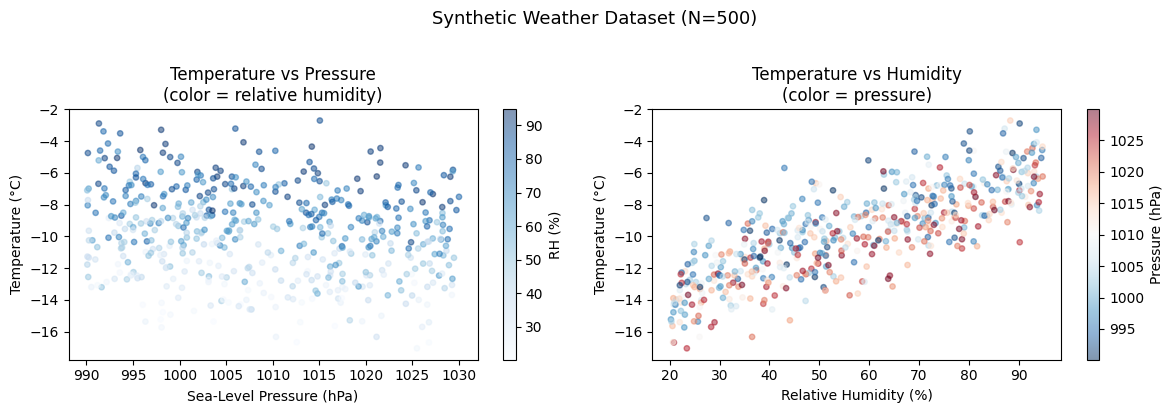

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Convert to NumPy for plotting (detach from computation graph first)
P_np  = pressure_raw.numpy()
RH_np = humidity_raw.numpy()
T_np  = y.numpy()

sc1 = axes[0].scatter(P_np, T_np, c=RH_np, cmap='Blues', alpha=0.5, s=15)
axes[0].set_xlabel("Sea-Level Pressure (hPa)")
axes[0].set_ylabel("Temperature (°C)")
axes[0].set_title("Temperature vs Pressure\n(color = relative humidity)")
plt.colorbar(sc1, ax=axes[0], label="RH (%)")

sc2 = axes[1].scatter(RH_np, T_np, c=P_np, cmap='RdBu_r', alpha=0.5, s=15)
axes[1].set_xlabel("Relative Humidity (%)")
axes[1].set_ylabel("Temperature (°C)")
axes[1].set_title("Temperature vs Humidity\n(color = pressure)")
plt.colorbar(sc2, ax=axes[1], label="Pressure (hPa)")

plt.suptitle("Synthetic Weather Dataset (N=500)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Automatic Differentiation <a id='autograd'></a>

This is PyTorch's **superpower**. Instead of deriving gradients by hand, PyTorch tracks every operation and computes derivatives automatically via `.backward()`.

**Why this matters for climate ML:**  
Training any neural network requires gradients of the loss with respect to every weight. Autograd does this for free, no matter how complex the model.

### How it works
1. Create tensors with `requires_grad=True` — these are the *learnable parameters*
2. Perform operations → PyTorch silently builds a **computation graph**
3. Call `.backward()` on a scalar loss → gradients flow back through the graph
4. Read `tensor.grad` → the gradient ∂loss/∂tensor

In [ ]:
# --- Manual linear regression via gradient descent ---
# We'll fit:  T_pred = w1*P + w2*RH + b
# and update w1, w2, b using autograd.

# Normalize inputs — important for stable training
X_mean = X.mean(dim=0)
X_std  = X.std(dim=0)
X_norm = (X - X_mean) / X_std       # shape [N, 2], zero mean, unit variance

y_mean = y.mean()
y_std  = y.std()
y_norm = (y - y_mean) / y_std       # normalize target too

# Initialize learnable parameters (random start)
w = torch.randn(2, requires_grad=True)    # weights for [pressure, humidity]
b = torch.zeros(1, requires_grad=True)    # bias

print("Initial parameters:")
print(f"  w = {w.detach().numpy().round(4)}")
print(f"  b = {b.detach().item():.4f}")

# --- One forward + backward pass to see autograd in action ---
y_pred = X_norm @ w + b                  # forward pass: linear prediction
loss   = ((y_pred - y_norm)**2).mean()   # mean squared error loss

print(f"\nLoss before any training: {loss.item():.4f}")
print(f"Loss tensor grad_fn     : {loss.grad_fn}  ← PyTorch built the graph")

loss.backward()    # ← compute all gradients in one call

print(f"\nGradients after .backward():")
print(f"  dLoss/dw = {w.grad.numpy().round(6)}")
print(f"  dLoss/db = {b.grad.item():.6f}")
print("\n→ These tell us which direction to nudge each parameter to reduce the loss.")

Initial parameters:
  w = [-0.1107 -0.2902]
  b = 0.0000

Loss before any training: 1.5210
Loss tensor grad_fn     : <MeanBackward0 object at 0x7b6da41e4eb0>  ← PyTorch built the graph

Gradients after .backward():
  dLoss/dw = [ 0.11765  -2.188452]
  dLoss/db = -0.000001

→ These tell us which direction to nudge each parameter to reduce the loss.


Training complete!
  Final loss: 0.3103

Recovered weights (physical units):
  w_pressure = -0.0526  (true: -0.0500)
  w_humidity = 0.1044  (true:  0.1000)
  bias       = 37.30    (true:  35.00)


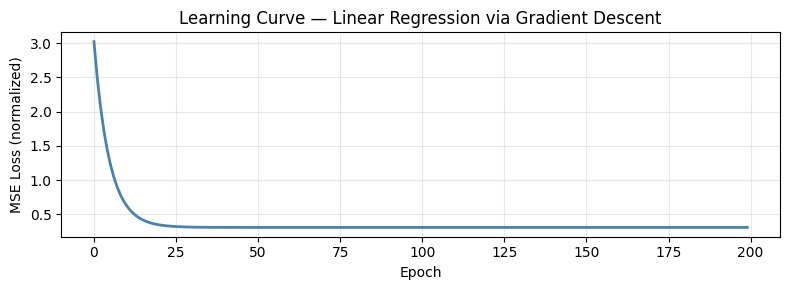

In [ ]:
# --- Full gradient descent training loop ---

# Re-initialize cleanly
w = torch.randn(2, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr = 0.05      # learning rate
epochs = 200
losses = []

for epoch in range(epochs):
    # 1. Forward pass
    y_pred = X_norm @ w + b
    loss   = ((y_pred - y_norm)**2).mean()
    losses.append(loss.item())

    # 2. Backward pass (compute gradients)
    loss.backward()

    # 3. Update parameters (no_grad prevents tracking this operation)
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    # 4. Zero gradients before next iteration (IMPORTANT — they accumulate otherwise)
    w.grad.zero_()
    b.grad.zero_()

# Recover physical weights (un-normalize)
w_physical = (w.detach() * y_std / X_std).numpy()
b_physical = (b.detach() * y_std + y_mean - (w.detach() * y_std / X_std * X_mean).sum()).item()

print("Training complete!")
print(f"  Final loss: {losses[-1]:.4f}")
print(f"\nRecovered weights (physical units):")
print(f"  w_pressure = {w_physical[0]:.4f}  (true: -0.0500)")
print(f"  w_humidity = {w_physical[1]:.4f}  (true:  0.1000)")
print(f"  bias       = {b_physical:.2f}    (true:  35.00)")

# Plot learning curve
plt.figure(figsize=(8, 3))
plt.plot(losses, color='steelblue', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (normalized)")
plt.title("Learning Curve — Linear Regression via Gradient Descent")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Mini Neural Network <a id='neural-network'></a>

Now we use PyTorch properly — with `nn.Module`, an optimizer, and mini-batches. This is the pattern used in real climate ML projects.

**Architecture:**
```
Input (2 features)  →  Linear(2→16)  →  ReLU  →  Linear(16→1)  →  Temperature prediction
```

Even for this simple linear dataset, this demonstrates the full workflow you'd use for a complex emulator or downscaling model.

In [ ]:
# --- Define the network ---

class WeatherNet(nn.Module):
    """2-layer MLP: pressure + humidity → temperature."""

    def __init__(self, hidden_size=16):
        super().__init__()
        self.layer1 = nn.Linear(2, hidden_size)   # 2 inputs → 16 hidden units
        self.act    = nn.ReLU()                   # nonlinear activation
        self.layer2 = nn.Linear(hidden_size, 1)   # 16 hidden → 1 output

    def forward(self, x):
        """x: tensor of shape [batch, 2]"""
        x = self.layer1(x)    # linear transform
        x = self.act(x)       # apply ReLU
        x = self.layer2(x)    # output layer
        return x.squeeze(-1)  # shape [batch] instead of [batch, 1]


model = WeatherNet(hidden_size=16).to(DEVICE)

# Print model summary
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params}")
# 2*16 + 16 (layer1) + 16*1 + 1 (layer2) = 32+16+16+1 = 65

WeatherNet(
  (layer1): Linear(in_features=2, out_features=16, bias=True)
  (act): ReLU()
  (layer2): Linear(in_features=16, out_features=1, bias=True)
)

Total trainable parameters: 65


In [ ]:
# --- Prepare data ---

# Train/validation split (80/20)
split = int(0.8 * N)
idx   = torch.randperm(N)

X_train, X_val = X_norm[idx[:split]], X_norm[idx[split:]]
y_train, y_val = y_norm[idx[:split]], y_norm[idx[split:]]

# Move to device (GPU if available)
X_train, y_train = X_train.to(DEVICE), y_train.to(DEVICE)
X_val,   y_val   = X_val.to(DEVICE),   y_val.to(DEVICE)

print(f"Training samples  : {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

# --- Loss function and optimizer ---
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# --- Training loop ---
EPOCHS     = 300
BATCH_SIZE = 64
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()   # training mode (enables dropout/batchnorm if used)

    # Shuffle and iterate in mini-batches
    perm = torch.randperm(X_train.shape[0], device=DEVICE)
    epoch_loss = 0.0
    n_batches = 0

    for start in range(0, X_train.shape[0], BATCH_SIZE):
        batch_idx  = perm[start : start + BATCH_SIZE]
        xb, yb     = X_train[batch_idx], y_train[batch_idx]

        optimizer.zero_grad()          # clear accumulated gradients
        pred  = model(xb)              # forward pass
        loss  = criterion(pred, yb)    # compute loss
        loss.backward()                # compute gradients
        optimizer.step()               # update weights

        epoch_loss += loss.item()
        n_batches  += 1

    train_losses.append(epoch_loss / n_batches)

    # Validation (no gradients needed)
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val).item()
    val_losses.append(val_loss)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  |  Train MSE: {train_losses[-1]:.4f}  |  Val MSE: {val_losses[-1]:.4f}")

print("\nTraining complete!")

Training samples  : 400
Validation samples: 100
Epoch  50/300  |  Train MSE: 0.3240  |  Val MSE: 0.2776
Epoch 100/300  |  Train MSE: 0.3021  |  Val MSE: 0.2752
Epoch 150/300  |  Train MSE: 0.3191  |  Val MSE: 0.2751
Epoch 200/300  |  Train MSE: 0.3197  |  Val MSE: 0.2748
Epoch 250/300  |  Train MSE: 0.2880  |  Val MSE: 0.2738
Epoch 300/300  |  Train MSE: 0.2924  |  Val MSE: 0.2775

Training complete!


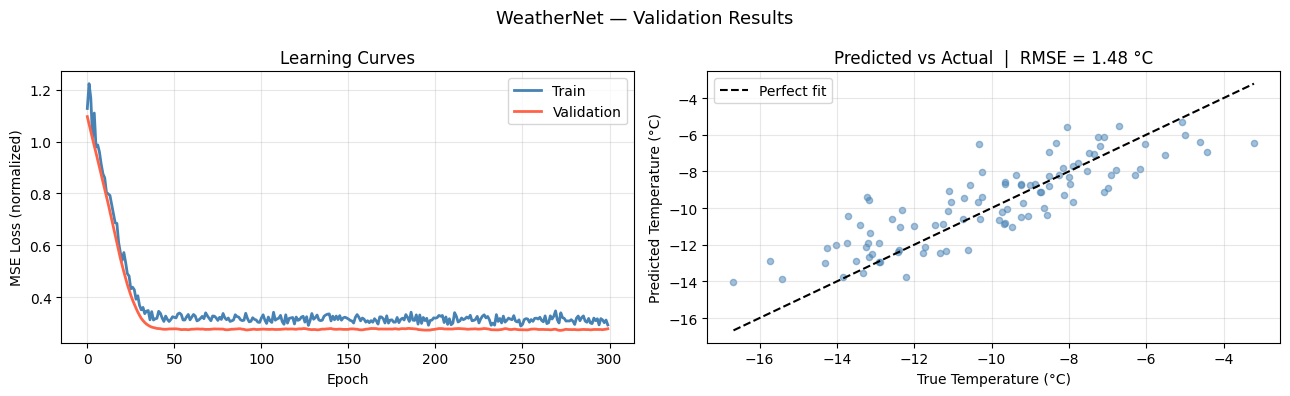

Validation RMSE: 1.48 °C  (noise level in data: ~1.5 °C)


In [ ]:
# --- Evaluate and visualize results ---

model.eval()
with torch.no_grad():
    val_pred_norm = model(X_val).cpu()

# Un-normalize predictions and targets back to °C
val_pred_C = val_pred_norm * y_std + y_mean
val_true_C = y_val.cpu() * y_std + y_mean

# Compute RMSE in physical units
rmse = ((val_pred_C - val_true_C)**2).mean().sqrt().item()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Learning curves
axes[0].plot(train_losses, label='Train', color='steelblue', linewidth=2)
axes[0].plot(val_losses,   label='Validation', color='tomato', linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss (normalized)")
axes[0].set_title("Learning Curves")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Predicted vs actual
t_min = min(val_true_C.min(), val_pred_C.min()).item()
t_max = max(val_true_C.max(), val_pred_C.max()).item()
axes[1].scatter(val_true_C.numpy(), val_pred_C.numpy(),
                alpha=0.5, s=20, color='steelblue')
axes[1].plot([t_min, t_max], [t_min, t_max], 'k--', linewidth=1.5, label='Perfect fit')
axes[1].set_xlabel("True Temperature (°C)")
axes[1].set_ylabel("Predicted Temperature (°C)")
axes[1].set_title(f"Predicted vs Actual  |  RMSE = {rmse:.2f} °C")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("WeatherNet — Validation Results", fontsize=13)
plt.tight_layout()
plt.show()
print(f"Validation RMSE: {rmse:.2f} °C  (noise level in data: ~1.5 °C)")

---
## 6. NumPy vs PyTorch Comparison <a id='numpy-vs-pytorch'></a>

Since most atmospheric scientists already know NumPy, here's a direct comparison of the same operations side-by-side.

**Key differences to remember:**
- PyTorch syntax is nearly identical to NumPy for array operations
- The big additions are: `.to(device)`, `requires_grad`, and `.backward()`
- Use `.numpy()` to go back to NumPy (must be on CPU first)

In [ ]:
# ============================================================
#  NUMPY vs PYTORCH — Side-by-side
# ============================================================

print("=" * 60)
print("TASK 1: Create a 5-element temperature array")
print("=" * 60)

# NumPy
temps_np = np.array([15.2, 18.7, 22.1, 19.4, 16.8])
print(f"NumPy  : {temps_np}  | type: {type(temps_np).__name__}")

# PyTorch
temps_pt = torch.tensor([15.2, 18.7, 22.1, 19.4, 16.8])
print(f"PyTorch: {temps_pt}  | type: {type(temps_pt).__name__}")

print()
print("=" * 60)
print("TASK 2: Compute mean and standard deviation")
print("=" * 60)
print(f"NumPy   mean: {np.mean(temps_np):.2f}   std: {np.std(temps_np):.2f}")
print(f"PyTorch mean: {temps_pt.mean():.2f}   std: {temps_pt.std():.2f}")
# Note: NumPy std uses ddof=0, PyTorch uses ddof=1 (Bessel's correction) by default

print()
print("=" * 60)
print("TASK 3: Matrix multiplication (e.g., apply a 2x2 transform)")
print("=" * 60)

A_np = np.array([[1.0, 0.5], [0.2, 1.0]])   # covariance-like matrix
v_np = np.array([1013.0, 65.0])              # [pressure, humidity] vector

A_pt = torch.tensor([[1.0, 0.5], [0.2, 1.0]])
v_pt = torch.tensor([1013.0, 65.0])

print(f"NumPy   A @ v: {A_np @ v_np}")
print(f"PyTorch A @ v: {A_pt @ v_pt}")

print()
print("=" * 60)
print("TASK 4: Reshape (e.g., flatten a 2D field)")
print("=" * 60)

field_np = np.random.randn(4, 6)
field_pt = torch.randn(4, 6)

print(f"NumPy   reshape(4,6) → (24,): {field_np.reshape(-1).shape}")
print(f"PyTorch reshape(4,6) → (24,): {field_pt.reshape(-1).shape}")
# PyTorch also has .view() which is slightly faster but requires contiguous memory

print()
print("=" * 60)
print("TASK 5: Converting between NumPy and PyTorch")
print("=" * 60)

# NumPy → PyTorch
era5_data_np = np.random.randn(100, 4).astype(np.float32)  # simulate ERA5 batch
era5_data_pt = torch.from_numpy(era5_data_np)               # zero-copy if on CPU!
print(f"np → torch : {era5_data_np.shape} → {era5_data_pt.shape}")

# PyTorch → NumPy
output_pt = torch.randn(100)           # model output
output_np = output_pt.detach().numpy() # .detach() removes it from the grad graph
print(f"torch → np : {output_pt.shape} → {output_np.shape}")

TASK 1: Create a 5-element temperature array
NumPy  : [15.2 18.7 22.1 19.4 16.8]  | type: ndarray
PyTorch: tensor([15.2000, 18.7000, 22.1000, 19.4000, 16.8000])  | type: Tensor

TASK 2: Compute mean and standard deviation
NumPy   mean: 18.44   std: 2.35
PyTorch mean: 18.44   std: 2.63

TASK 3: Matrix multiplication (e.g., apply a 2x2 transform)
NumPy   A @ v: [1045.5  267.6]
PyTorch A @ v: tensor([1045.5000,  267.6000])

TASK 4: Reshape (e.g., flatten a 2D field)
NumPy   reshape(4,6) → (24,): (24,)
PyTorch reshape(4,6) → (24,): torch.Size([24])

TASK 5: Converting between NumPy and PyTorch
np → torch : (100, 4) → torch.Size([100, 4])
torch → np : torch.Size([100]) → (100,)


In [ ]:
# --- Same task, two implementations: compute a spatial anomaly field ---
# Subtract the temporal mean at each grid point

print("Task: Compute temperature anomaly (T - T_mean) over a 12x8 grid, 50 timesteps")
print("")

# Simulate a (time, lat, lon) temperature field
T_np_field = np.random.randn(50, 12, 8).astype(np.float32) * 5 + 15  # (time, lat, lon)

# ---- NumPy approach ----
start = time.time()
T_mean_np  = T_np_field.mean(axis=0, keepdims=True)   # shape (1, 12, 8)
T_anom_np  = T_np_field - T_mean_np                   # broadcast subtraction
np_time = time.time() - start

# ---- PyTorch approach ----
T_pt_field = torch.from_numpy(T_np_field).to(DEVICE)

torch.cuda.synchronize() if torch.cuda.is_available() else None
start = time.time()
T_mean_pt  = T_pt_field.mean(dim=0, keepdim=True)     # same logic, PyTorch syntax
T_anom_pt  = T_pt_field - T_mean_pt
torch.cuda.synchronize() if torch.cuda.is_available() else None
pt_time = time.time() - start

# Verify they agree
T_anom_pt_cpu = T_anom_pt.cpu().numpy()
max_diff = np.abs(T_anom_np - T_anom_pt_cpu).max()

print(f"NumPy   anomaly field shape : {T_anom_np.shape}")
print(f"PyTorch anomaly field shape : {T_anom_pt.shape}")
print(f"Max absolute difference     : {max_diff:.2e}  ← essentially zero")
print(f"\nKey syntax differences:")
print(f"  NumPy  : arr.mean(axis=0, keepdims=True)")
print(f"  PyTorch: tensor.mean(dim=0, keepdim=True)   ← axis→dim, keepdims→keepdim")

Task: Compute temperature anomaly (T - T_mean) over a 12x8 grid, 50 timesteps

NumPy   anomaly field shape : (50, 12, 8)
PyTorch anomaly field shape : torch.Size([50, 12, 8])
Max absolute difference     : 5.72e-06  ← essentially zero

Key syntax differences:
  NumPy  : arr.mean(axis=0, keepdims=True)
  PyTorch: tensor.mean(dim=0, keepdim=True)   ← axis→dim, keepdims→keepdim


In [ ]:
# --- Quick-reference cheatsheet ---

cheatsheet = """
╔══════════════════════════════════════════════════════════════════╗
║         NumPy → PyTorch Quick Reference                         ║
╠══════════════════════════╦═══════════════════════════════════════╣
║ NumPy                    ║ PyTorch                               ║
╠══════════════════════════╬═══════════════════════════════════════╣
║ np.array([1,2,3])        ║ torch.tensor([1,2,3])                 ║
║ np.zeros((3,4))          ║ torch.zeros(3,4)                      ║
║ np.ones((3,4))           ║ torch.ones(3,4)                       ║
║ np.random.randn(3,4)     ║ torch.randn(3,4)                      ║
║ arr.reshape(-1)          ║ tensor.reshape(-1) / .view(-1)        ║
║ arr.mean(axis=0)         ║ tensor.mean(dim=0)                    ║
║ arr.std(axis=1)          ║ tensor.std(dim=1)                     ║
║ A @ B                    ║ A @ B  or  torch.matmul(A, B)         ║
║ np.concatenate([a,b])    ║ torch.cat([a,b])                      ║
║ np.stack([a,b])          ║ torch.stack([a,b])                    ║
║ arr[arr > 0]             ║ tensor[tensor > 0]                    ║
║ np.sqrt(arr)             ║ torch.sqrt(tensor)                    ║
║ np.exp(arr)              ║ torch.exp(tensor)                     ║
║ np.save / np.load        ║ torch.save / torch.load               ║
╠══════════════════════════╬═══════════════════════════════════════╣
║ PyTorch-only             ║                                       ║
╠══════════════════════════╬═══════════════════════════════════════╣
║ tensor.to(device)        ║ move to CPU/GPU                       ║
║ tensor.cuda()            ║ move to GPU (shorthand)               ║
║ tensor.cpu()             ║ move to CPU                           ║
║ tensor.detach().numpy()  ║ convert to NumPy array                ║
║ torch.from_numpy(arr)    ║ convert from NumPy (shared memory)    ║
║ requires_grad=True       ║ track for autograd                    ║
║ loss.backward()          ║ compute all gradients                 ║
║ optimizer.zero_grad()    ║ clear gradients before each step      ║
║ model.eval()             ║ disable dropout/batchnorm training    ║
║ torch.no_grad()          ║ context manager: no gradient tracking ║
╚══════════════════════════╩═══════════════════════════════════════╝
"""
print(cheatsheet)


╔══════════════════════════════════════════════════════════════════╗
║         NumPy → PyTorch Quick Reference                         ║
╠══════════════════════════╦═══════════════════════════════════════╣
║ NumPy                    ║ PyTorch                               ║
╠══════════════════════════╬═══════════════════════════════════════╣
║ np.array([1,2,3])        ║ torch.tensor([1,2,3])                 ║
║ np.zeros((3,4))          ║ torch.zeros(3,4)                      ║
║ np.ones((3,4))           ║ torch.ones(3,4)                       ║
║ np.random.randn(3,4)     ║ torch.randn(3,4)                      ║
║ arr.reshape(-1)          ║ tensor.reshape(-1) / .view(-1)        ║
║ arr.mean(axis=0)         ║ tensor.mean(dim=0)                    ║
║ arr.std(axis=1)          ║ tensor.std(dim=1)                     ║
║ A @ B                    ║ A @ B  or  torch.matmul(A, B)         ║
║ np.concatenate([a,b])    ║ torch.cat([a,b])                      ║
║ np.stack([a,b])          ║ torch

---
## Summary & Next Steps

### What you learned

| Topic | Key takeaway |
|---|---|
| **Tensors** | Multidimensional arrays that can live on CPU or GPU |
| **GPU operations** | `.to(device)` or `.cuda()` — everything else stays the same |
| **Autograd** | `requires_grad=True` + `.backward()` = free gradient computation |
| **`nn.Module`** | Clean way to define, train, and save neural networks |
| **Training loop** | forward → loss → backward → step → zero_grad |
| **NumPy bridge** | `torch.from_numpy()` / `.detach().numpy()` — almost zero friction |

---

### Suggested next steps for climate/weather applications

1. **`torch.utils.data.DataLoader`** — efficient batching from netCDF/xarray data  
2. **Convolutional networks (`nn.Conv2d`)** — spatial fields, downscaling  
3. **LSTM / Transformer (`nn.LSTM`, `nn.TransformerEncoder`)** — time series forecasting  
4. **`torch.save` / `torch.load`** — saving trained models for reuse  
5. **Weights & Biases (`wandb`)** — experiment tracking for long climate ML runs

---

### Helpful resources

- [PyTorch official tutorials](https://pytorch.org/tutorials/) — comprehensive, well-maintained  
- [ClimateLearn](https://github.com/aditya-grover/climate-learn) — benchmark datasets and baselines for climate ML  
- [ClimateBench](https://github.com/duncanwp/ClimateBench) — ML emulation of climate models  
- [NeurIPS 2023 Climate Change AI workshop](https://www.climatechange.ai/events/neurips2023) — cutting-edge applications

---
*Tutorial written for PyTorch ≥ 2.0. Tested on Google Colab with T4 GPU.*